## Lab Assignment 6


In [3]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


## PART A

### Load and inspect the images

In [7]:
crack_path = "data/asphalt/Cracks"
noncrack_path = "data/asphalt/NonCracks"

crack_files = os.listdir(crack_path)
noncrack_files = os.listdir(noncrack_path)

print("Crack images:", len(crack_files))
print("Non-crack images:", len(noncrack_files))
print("Total images:", len(crack_files) + len(noncrack_files))

Crack images: 200
Non-crack images: 200
Total images: 400


### Inspect One Image

In [8]:
sample_file = crack_files[0]
sample_path = os.path.join(crack_path, sample_file)

image = cv2.imread(sample_path)

print("Image file:", sample_file)
print("Image shape:", image.shape)
print("Image height:", image.shape[0])
print("Image width:", image.shape[1])
print("Number of channels:", image.shape[2])

Image file: IMG_20180513_164959951_HDR resized_448.jpg
Image shape: (448, 448, 3)
Image height: 448
Image width: 448
Number of channels: 3


### Resize + Grayscale One Image

In [9]:
resized = cv2.resize(image, (224, 224))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

print("Original shape:", image.shape)
print("Resized shape:", resized.shape)
print("Grayscale shape:", gray.shape)

Original shape: (448, 448, 3)
Resized shape: (224, 224, 3)
Grayscale shape: (224, 224)


### Visualize the images

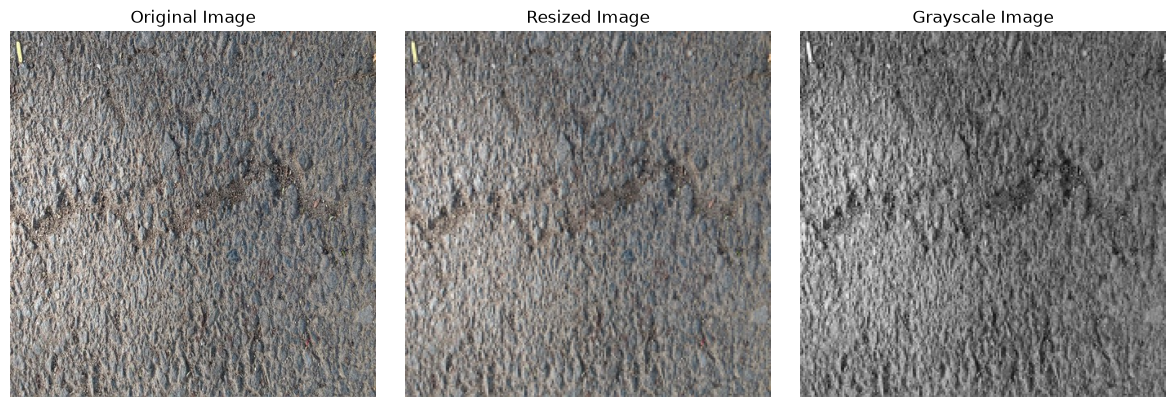

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

### Extract basic intensity features

In [11]:
mean_brightness = np.mean(gray)
contrast = np.std(gray)
min_intensity = np.min(gray)
max_intensity = np.max(gray)
median_intensity = np.median(gray)

print("Mean brightness:", mean_brightness)
print("Contrast:", contrast)
print("Minimum intensity:", min_intensity)
print("Maximum intensity:", max_intensity)
print("Median intensity:", median_intensity)

Mean brightness: 122.224609375
Contrast: 31.51348191896166
Minimum intensity: 23
Maximum intensity: 247
Median intensity: 121.0


### Dark and bright pixel ratios

In [12]:
dark_pixel_ratio = np.mean(gray < 50)
bright_pixel_ratio = np.mean(gray > 200)

print("Dark pixel ratio:", dark_pixel_ratio)
print("Bright pixel ratio:", bright_pixel_ratio)

Dark pixel ratio: 0.0038464604591836736
Bright pixel ratio: 0.01092155612244898


### Detect edges using Canny

In [13]:
edges = cv2.Canny(gray, 100, 200)

edge_count = np.sum(edges > 0)
edge_density = edge_count / edges.size

print("Edge count:", edge_count)
print("Edge density:", edge_density)

Edge count: 17232
Edge density: 0.3434311224489796


### Visualize the Canny edges

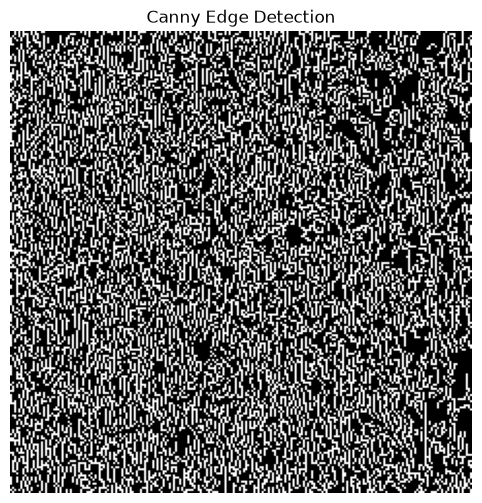

In [14]:
plt.figure(figsize=(6, 6))

plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

### Create a feature extraction function

In [15]:
def extract_features(image_path):
    image = cv2.imread(image_path)

    resized = cv2.resize(image, (224, 224))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    return [
        mean_brightness,
        contrast,
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]


features = extract_features(sample_path)

print("Extracted features:")
print(features)

Extracted features:
[np.float64(122.224609375), np.float64(31.51348191896166), np.uint8(23), np.uint8(247), np.float64(121.0), np.float64(0.0038464604591836736), np.float64(0.01092155612244898), np.int64(17232), np.float64(0.3434311224489796)]


### Extract features from all 400 images

In [16]:
all_features = []
all_labels = []

image_folders = [
    (crack_path, 1),
    (noncrack_path, 0)
]

for folder, label in image_folders:
    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_path = os.path.join(folder, file)

            features = extract_features(image_path)

            all_features.append(features)
            all_labels.append(label)

feature_names = [
    "mean_brightness",
    "contrast",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

features_df = pd.DataFrame(all_features, columns=feature_names)
features_df["label"] = all_labels

print("Feature table shape:", features_df.shape)
print("\nFirst 5 rows:")
print(features_df.head())

Feature table shape: (400, 10)

First 5 rows:
   mean_brightness   contrast  min_intensity  max_intensity  median_intensity  \
0       122.224609  31.513482             23            247             121.0   
1       131.948681  24.096114              8            251             133.0   
2       121.297313  29.884272              2            241             121.0   
3       130.245596  25.649018             20            253             131.0   
4       131.208885  26.237598             11            254             132.0   

   dark_pixel_ratio  bright_pixel_ratio  edge_count  edge_density  label  
0          0.003846            0.010922       17232      0.343431      1  
1          0.002790            0.003787       13394      0.266940      1  
2          0.013333            0.008171       13185      0.262775      1  
3          0.001893            0.004006       16591      0.330656      1  
4          0.002372            0.006258       15886      0.316606      1  


### Check the class distribution

In [17]:
print("Class distribution:")

print("\n0 = Non-crack")
print("1 = Crack")

print(features_df["label"].value_counts())

Class distribution:

0 = Non-crack
1 = Crack
label
1    200
0    200
Name: count, dtype: int64


### Save the extracted feature table

In [19]:
os.makedirs("outputs", exist_ok=True)

features_df.to_csv("outputs/image_features.csv", index=False)


### Prepare features and labels

In [20]:
X = features_df.drop("label", axis=1)
y = features_df["label"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (400, 9)
Labels shape: (400,)


### Split the data into training and testing sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


### Train Logistic Regression

In [23]:
model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

start_time = time.perf_counter()

model_lr.fit(X_train, y_train)

training_time_lr = time.perf_counter() - start_time

print("Training time:", training_time_lr, "seconds")

Training time: 0.012459800000215182 seconds


### Make predictions and measure prediction time

In [24]:
start_time = time.perf_counter()

y_pred_lr = model_lr.predict(X_test)

prediction_time_lr = time.perf_counter() - start_time

print("Prediction time:", prediction_time_lr, "seconds")

Prediction time: 0.002151600000615872 seconds


### Evaluate Logistic Regression

In [25]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

print("\nConfusion Matrix:")
print(cm_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.9375
Precision: 0.926829268292683
Recall   : 0.95
F1 Score : 0.9382716049382716

Confusion Matrix:
[[37  3]
 [ 2 38]]


### Visualize the confusion matrix

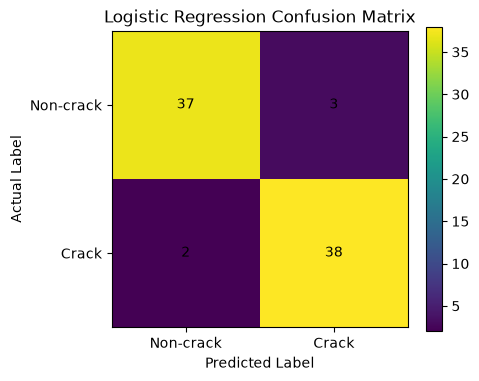

In [26]:
plt.figure(figsize=(5, 4))

plt.imshow(cm_lr)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-crack", "Crack"])
plt.yticks([0, 1], ["Non-crack", "Crack"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

### Train Random Forest

In [28]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_time = time.perf_counter()

model_rf.fit(X_train, y_train)

training_time_rf = time.perf_counter() - start_time
print("Training time:", training_time_rf, "seconds")

Training time: 0.13576449999982287 seconds


### Make Random Forest predictions

In [30]:
start_time = time.perf_counter()

y_pred_rf = model_rf.predict(X_test)

prediction_time_rf = time.perf_counter() - start_time
print("Prediction time:", prediction_time_rf, "seconds")

Prediction time: 0.012003799999547482 seconds


### Evaluate Random Forest

In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

print("\nConfusion Matrix:")
print(cm_rf)

Random Forest Results
---------------------
Accuracy : 0.95
Precision: 0.95
Recall   : 0.95
F1 Score : 0.95

Confusion Matrix:
[[38  2]
 [ 2 38]]


### Compare the two models

In [32]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1 Score": [f1_lr, f1_rf],
    "Training Time (s)": [training_time_lr, training_time_rf],
    "Prediction Time (s)": [prediction_time_lr, prediction_time_rf]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score  \
0  Logistic Regression    0.9375   0.926829    0.95  0.938272   
1        Random Forest    0.9500   0.950000    0.95  0.950000   

   Training Time (s)  Prediction Time (s)  
0           0.012460             0.002152  
1           0.135764             0.012004  


In [33]:
results.to_csv("outputs/image_model_comparison.csv", index=False)

In [34]:
cv2.imwrite("outputs/sample_canny_edges.jpg", edges)

True

### Summary

In [36]:

print("\nDataset")
print("Total images:", len(features_df))
print("Crack images:", sum(y == 1))
print("Non-crack images:", sum(y == 0))

print("\nFeatures extracted:", len(feature_names))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nModel Results")
print(results.to_string(index=False))


Dataset
Total images: 400
Crack images: 200
Non-crack images: 200

Features extracted: 9
Training samples: 320
Testing samples: 80

Model Results
              Model  Accuracy  Precision  Recall  F1 Score  Training Time (s)  Prediction Time (s)
Logistic Regression    0.9375   0.926829    0.95  0.938272           0.012460             0.002152
      Random Forest    0.9500   0.950000    0.95  0.950000           0.135764             0.012004


----------------------
## Part B

### Load the email dataset

In [37]:
email_path = "data/emails.csv"

emails_df = pd.read_csv(email_path)

print("Dataset shape:", emails_df.shape)
print("\nColumn names:")
print(emails_df.columns.tolist())

print("\nFirst 5 rows:")
print(emails_df.head())

Dataset shape: (5172, 3002)

Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'h

### Check the spam/non-spam distribution

In [38]:
print("Prediction distribution:")

print(emails_df["Prediction"].value_counts())

print("\nPrediction percentages:")
print(emails_df["Prediction"].value_counts(normalize=True) * 100)

Prediction distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Prediction percentages:
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64


### Separate features and target

In [39]:
X_text = emails_df.drop(["Email No.", "Prediction"], axis=1)
y_text = emails_df["Prediction"]

print("Text features shape:", X_text.shape)
print("Target shape:", y_text.shape)


Text features shape: (5172, 3000)
Target shape: (5172,)


### Split the text data into training and testing sets

In [40]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=42,
    stratify=y_text
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4137
Testing samples: 1035


### Train Logistic Regression on the existing word-count features

In [42]:
model_text_count = LogisticRegression(
    max_iter=1000
)

start_time = time.perf_counter()

model_text_count.fit(X_train_text, y_train_text)

training_time_text_count = time.perf_counter() - start_time

print("Training time:", training_time_text_count, "seconds")

Training time: 7.2774005000001125 seconds


### Predict the test emails

In [43]:
start_time = time.perf_counter()

y_pred_text_count = model_text_count.predict(X_test_text)

prediction_time_text_count = time.perf_counter() - start_time

print("Prediction time:", prediction_time_text_count, "seconds")

Prediction time: 0.06779079999978421 seconds


### Evaluate the Count-based Logistic Regression model

In [44]:
accuracy_text_count = accuracy_score(y_test_text, y_pred_text_count)
precision_text_count = precision_score(
    y_test_text, y_pred_text_count, zero_division=0
)
recall_text_count = recall_score(
    y_test_text, y_pred_text_count, zero_division=0
)
f1_text_count = f1_score(
    y_test_text, y_pred_text_count, zero_division=0
)
cm_text_count = confusion_matrix(
    y_test_text, y_pred_text_count
)

print("Logistic Regression - Count Features")
print("-------------------------------------")
print("Accuracy :", accuracy_text_count)
print("Precision:", precision_text_count)
print("Recall   :", recall_text_count)
print("F1 Score :", f1_text_count)

print("\nConfusion Matrix:")
print(cm_text_count)

Logistic Regression - Count Features
-------------------------------------
Accuracy : 0.9826086956521739
Precision: 0.9577922077922078
Recall   : 0.9833333333333333
F1 Score : 0.9703947368421053

Confusion Matrix:
[[722  13]
 [  5 295]]


### Convert Count Features to TF-IDF

In [45]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()

X_train_tfidf = tfidf_transformer.fit_transform(X_train_text)
X_test_tfidf = tfidf_transformer.transform(X_test_text)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (4137, 3000)
TF-IDF testing shape: (1035, 3000)


### Train Logistic Regression using TF-IDF

In [47]:
model_text_tfidf = LogisticRegression(
    max_iter=1000
)

start_time = time.perf_counter()

model_text_tfidf.fit(X_train_tfidf, y_train_text)

training_time_text_tfidf = time.perf_counter() - start_time
print("Training time:", training_time_text_tfidf, "seconds")

Training time: 0.09880140000041138 seconds


### Predict using the TF-IDF model

In [48]:
start_time = time.perf_counter()

y_pred_text_tfidf = model_text_tfidf.predict(X_test_tfidf)

prediction_time_text_tfidf = time.perf_counter() - start_time

print("Prediction time:", prediction_time_text_tfidf, "seconds")

Prediction time: 0.0015057999999044114 seconds


### Evaluate the TF-IDF model

In [49]:
accuracy_text_tfidf = accuracy_score(y_test_text, y_pred_text_tfidf)
precision_text_tfidf = precision_score(
    y_test_text, y_pred_text_tfidf, zero_division=0
)
recall_text_tfidf = recall_score(
    y_test_text, y_pred_text_tfidf, zero_division=0
)
f1_text_tfidf = f1_score(
    y_test_text, y_pred_text_tfidf, zero_division=0
)
cm_text_tfidf = confusion_matrix(
    y_test_text, y_pred_text_tfidf
)

print("Logistic Regression - TF-IDF Features")
print("Accuracy :", accuracy_text_tfidf)
print("Precision:", precision_text_tfidf)
print("Recall   :", recall_text_tfidf)
print("F1 Score :", f1_text_tfidf)

print("\nConfusion Matrix:")
print(cm_text_tfidf)

Logistic Regression - TF-IDF Features
Accuracy : 0.9507246376811594
Precision: 0.9307958477508651
Recall   : 0.8966666666666666
F1 Score : 0.9134125636672326

Confusion Matrix:
[[715  20]
 [ 31 269]]


### Compare Count vs TF-IDF

In [50]:
text_results = pd.DataFrame({
    "Representation": ["Count Features", "TF-IDF"],
    "Number of Features": [
        X_train_text.shape[1],
        X_train_tfidf.shape[1]
    ],
    "Accuracy": [
        accuracy_text_count,
        accuracy_text_tfidf
    ],
    "Precision": [
        precision_text_count,
        precision_text_tfidf
    ],
    "Recall": [
        recall_text_count,
        recall_text_tfidf
    ],
    "F1 Score": [
        f1_text_count,
        f1_text_tfidf
    ],
    "Training Time (s)": [
        training_time_text_count,
        training_time_text_tfidf
    ],
    "Prediction Time (s)": [
        prediction_time_text_count,
        prediction_time_text_tfidf
    ]
})

print(text_results)

   Representation  Number of Features  Accuracy  Precision    Recall  \
0  Count Features                3000  0.982609   0.957792  0.983333   
1          TF-IDF                3000  0.950725   0.930796  0.896667   

   F1 Score  Training Time (s)  Prediction Time (s)  
0  0.970395           7.277401             0.067791  
1  0.913413           0.098801             0.001506  


### Save Part B results

In [51]:
text_results.to_csv(
    "outputs/text_vectorization_comparison.csv",
    index=False
)

### Create a confusion matrix for the TF-IDF model

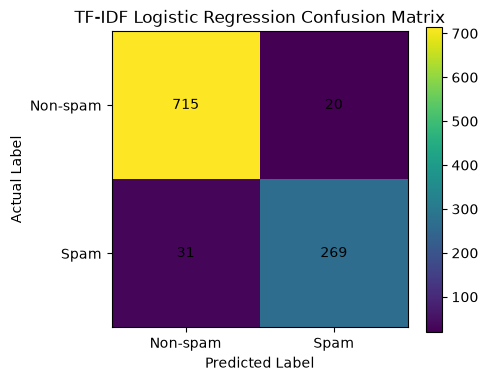

In [52]:
plt.figure(figsize=(5, 4))

plt.imshow(cm_text_tfidf)

plt.title("TF-IDF Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-spam", "Spam"])
plt.yticks([0, 1], ["Non-spam", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_text_tfidf[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### summary

In [53]:
print("PART B - TEXT CLASSIFICATION SUMMARY")

print("\nDataset")
print("Total emails:", len(emails_df))
print("Non-spam emails:", sum(y_text == 0))
print("Spam emails:", sum(y_text == 1))

print("\nFeatures")
print("Number of features:", X_text.shape[1])

print("\nModel Results")
print(text_results.to_string(index=False))

PART B - TEXT CLASSIFICATION SUMMARY

Dataset
Total emails: 5172
Non-spam emails: 3672
Spam emails: 1500

Features
Number of features: 3000

Model Results
Representation  Number of Features  Accuracy  Precision   Recall  F1 Score  Training Time (s)  Prediction Time (s)
Count Features                3000  0.982609   0.957792 0.983333  0.970395           7.277401             0.067791
        TF-IDF                3000  0.950725   0.930796 0.896667  0.913413           0.098801             0.001506


-----------------------
## PART C

### Create the improved feature extraction function

In [55]:
def extract_improved_features(image_path):
    image = cv2.imread(image_path)
    resized = cv2.resize(image, (224, 224))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    # Improved Canny representation
    edges = cv2.Canny(gray, 50, 150)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    return [
        mean_brightness,
        contrast,
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]


### Extract improved features from all 400 images

In [56]:
improved_features = []
improved_labels = []

for folder, label in image_folders:
    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_path = os.path.join(folder, file)

            features = extract_improved_features(image_path)

            improved_features.append(features)
            improved_labels.append(label)

improved_features_df = pd.DataFrame(
    improved_features,
    columns=feature_names
)

improved_features_df["label"] = improved_labels

print("Improved feature table shape:", improved_features_df.shape)
print("\nFirst 5 rows:")
print(improved_features_df.head())

Improved feature table shape: (400, 10)

First 5 rows:
   mean_brightness   contrast  min_intensity  max_intensity  median_intensity  \
0       122.224609  31.513482             23            247             121.0   
1       131.948681  24.096114              8            251             133.0   
2       121.297313  29.884272              2            241             121.0   
3       130.245596  25.649018             20            253             131.0   
4       131.208885  26.237598             11            254             132.0   

   dark_pixel_ratio  bright_pixel_ratio  edge_count  edge_density  label  
0          0.003846            0.010922       18520      0.369101      1  
1          0.002790            0.003787       18094      0.360611      1  
2          0.013333            0.008171       17454      0.347856      1  
3          0.001893            0.004006       18767      0.374023      1  
4          0.002372            0.006258       18349      0.365693      1  


### Prepare improved features for training

In [57]:
X_improved = improved_features_df.drop("label", axis=1)
y_improved = improved_features_df["label"]

X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved
)

print("Improved training samples:", len(X_train_improved))
print("Improved testing samples:", len(X_test_improved))
print("Number of features:", X_improved.shape[1])

Improved training samples: 320
Improved testing samples: 80
Number of features: 9


### Train Random Forest with the improved features

In [58]:
model_rf_improved = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_time = time.perf_counter()

model_rf_improved.fit(X_train_improved, y_train_improved)

training_time_rf_improved = time.perf_counter() - start_time

print("Training time:", training_time_rf_improved, "seconds")


Training time: 0.12950240000100166 seconds


### Predict with the improved Random Forest

In [60]:
start_time = time.perf_counter()

y_pred_rf_improved = model_rf_improved.predict(X_test_improved)

prediction_time_rf_improved = time.perf_counter() - start_time

print("Prediction time:", prediction_time_rf_improved, "seconds")

Prediction time: 0.01290070000140986 seconds


### Evaluate the improved Random Forest

In [64]:
accuracy_rf_improved = accuracy_score(
    y_test_improved, y_pred_rf_improved
)

precision_rf_improved = precision_score(
    y_test_improved, y_pred_rf_improved, zero_division=0
)

recall_rf_improved = recall_score(
    y_test_improved, y_pred_rf_improved, zero_division=0
)

f1_rf_improved = f1_score(
    y_test_improved, y_pred_rf_improved, zero_division=0
)

cm_rf_improved = confusion_matrix(
    y_test_improved, y_pred_rf_improved
)

print("Improved Random Forest Results")
print("Accuracy :", accuracy_rf_improved)
print("Precision:", precision_rf_improved)
print("Recall   :", recall_rf_improved)
print("F1 Score :", f1_rf_improved)

print("\nConfusion Matrix:")
print(cm_rf_improved)

Improved Random Forest Results
Accuracy : 0.95
Precision: 0.95
Recall   : 0.95
F1 Score : 0.95

Confusion Matrix:
[[38  2]
 [ 2 38]]


### Compare Original vs Improved Image Representation

In [65]:
image_part_c_results = pd.DataFrame({
    "Representation": [
        "Original Canny (100, 200)",
        "Improved Canny (50, 150)"
    ],
    "Features": [
        X.shape[1],
        X_improved.shape[1]
    ],
    "Accuracy": [
        accuracy_rf,
        accuracy_rf_improved
    ],
    "Precision": [
        precision_rf,
        precision_rf_improved
    ],
    "Recall": [
        recall_rf,
        recall_rf_improved
    ],
    "F1 Score": [
        f1_rf,
        f1_rf_improved
    ],
    "Training Time (s)": [
        training_time_rf,
        training_time_rf_improved
    ],
    "Prediction Time (s)": [
        prediction_time_rf,
        prediction_time_rf_improved
    ]
})

print(image_part_c_results)

              Representation  Features  Accuracy  Precision  Recall  F1 Score  \
0  Original Canny (100, 200)         9      0.95       0.95    0.95      0.95   
1   Improved Canny (50, 150)         9      0.95       0.95    0.95      0.95   

   Training Time (s)  Prediction Time (s)  
0           0.135764             0.012004  
1           0.129502             0.012901  


In [66]:
image_part_c_results.to_csv(
    "outputs/image_representation_comparison.csv",
    index=False
)

In [67]:
improved_features_df.to_csv(
    "outputs/improved_image_features.csv",
    index=False
)

### Part C - Feature Improvement

In Part C, changed the Canny edge detection thresholds from **(100, 200)** to **(50, 150)**. The main idea was to detect some additional edges in the images and check whether this would improve the classification results.

Both versions used the same 9 features and the same train-test split. The accuracy, precision, recall and F1 score were **0.95** for both approaches.

The training time was also very close. The original version took about **0.136 seconds**, while the improved version took about **0.130 seconds**. The prediction times were also almost the same.

Therefore, changing the Canny thresholds did not improve the classification accuracy in this experiment. However, it showed that we can change the image representation without increasing the number of features. In this case, the change had very little effect on computation time and model performance.